In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import shap
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score, 
    recall_score, 
    f1_score
)

In [67]:
# custom functions

def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

### Using the Preprocessed Minimal NFI dataset
This includes all 89 original elements because XGBoost can handle the sparsity.

In [68]:
df = pd.read_parquet("../../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

In [69]:
# NFI column sort
nfi_meta = ['stub_id', 'particle_id', 'class', 'label', 'target']
element_cols = [c for c in df.columns if c not in nfi_meta]
gsr = ['pb', 'sb', 'ba']
non_gsr = sorted([c for c in element_cols if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

print(f"# of elements: {len(element_cols)}")

# of elements: 89


In [70]:
nfi_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'bi', 'br', 'ca', 'cd',
       'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr',
       'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la',
       'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o',
       'os', 'p', 'pa', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're',
       'rh', 'rn', 'ru', 's', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb',
       'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb',
       'zn', 'zr'],
      dtype='str')

### Re-engineer Features

In [71]:
eng_df = nfi_df.copy()

In [72]:
# Pb * Sb
eng_df['pb_times_sb'] = eng_df['pb'] * (eng_df['sb'])

In [73]:
# Log (Pb + Sb)
# eng_df['log_pb_plus_sb'] = np.log1p(eng_df['pb'] + eng_df['sb'])

In [74]:
# GSR ratios over total mass
total_mass = eng_df[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_df['sb']
total_mass_no_ba = total_mass - eng_df['ba']
total_mass_no_pb = total_mass - eng_df['pb']

eng_df['pb_ba_over_non_sb_mass'] = (eng_df['pb'] + eng_df['ba']) / total_mass_no_sb
eng_df['pb_sb_over_non_ba_mass'] =  (eng_df['pb'] + eng_df['sb']) / total_mass_no_ba
eng_df['ba_sb_over_non_pb_mass'] =  (eng_df['ba'] + eng_df['sb']) / total_mass_no_pb

In [75]:
# Brass particles
eng_df['cu_zn_over_mass'] =  (eng_df['cu'] + eng_df['zn']) / total_mass

# Titanium Zinc
eng_df['ti_zn_over_mass'] = (eng_df['ti'] + eng_df['zn']) / total_mass

In [76]:
# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df['pb'] + eng_df['sb']
confounders = eng_df['ca'] + eng_df['si'] + eng_df['al'] + eng_df['fe'] #+ eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df['gsr_over_confounders']) | eng_df['gsr_over_confounders'].isna())

False

In [77]:
eng_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ac', 'ag',
       ...
       'yb', 'zn', 'zr', 'pb_times_sb', 'pb_ba_over_non_sb_mass',
       'pb_sb_over_non_ba_mass', 'ba_sb_over_non_pb_mass', 'cu_zn_over_mass',
       'ti_zn_over_mass', 'gsr_over_confounders'],
      dtype='str', length=101)

In [78]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta + element_cols]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 7

Engineered features:
	pb_times_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


__7 engineered features + 89 raw element features__

In [79]:
feature_cols = element_cols + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 96


### Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [80]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df['target'].values.astype(np.float32)
groups = eng_df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [81]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


Summarize the train/val/test split

In [82]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 96
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


# Final Baseline

Default threshold = 0.5

In [83]:
baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99907	validation_1-aucpr:0.99926
[10]	validation_0-aucpr:0.99990	validation_1-aucpr:0.99994
[20]	validation_0-aucpr:0.99996	validation_1-aucpr:0.99998
[30]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[50]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[99]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

__Eval Baseline train & val learning curves__

In [84]:
results = baseline.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

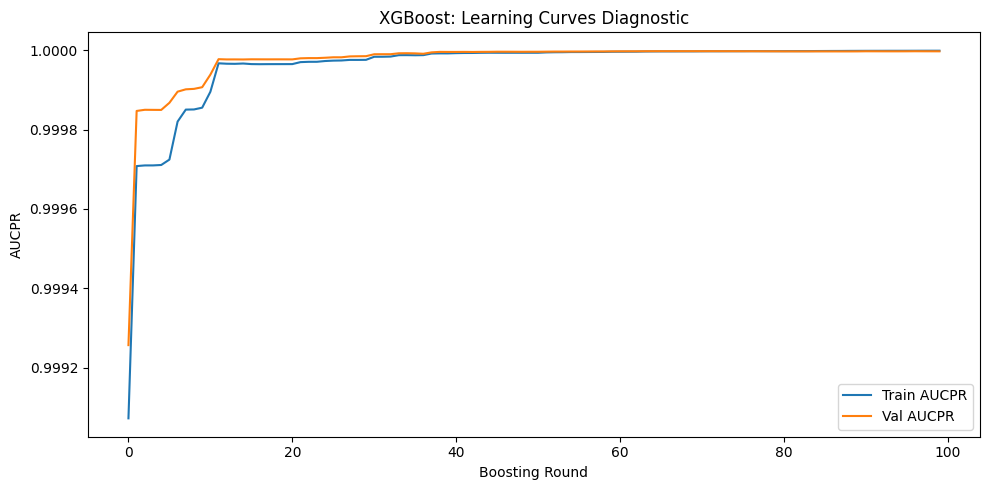

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('XGBoost: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curves_final.png', dpi=150)
plt.show()

In [86]:
# Feature Importance
importances = baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"Final Baseline: Top 20 Important Features\n\n{feat_imp.head(20)}")

Final Baseline: Top 20 Important Features

pb_sb_over_non_ba_mass    0.733378
pb                        0.204811
gsr_over_confounders      0.015888
sb                        0.013364
pb_ba_over_non_sb_mass    0.011384
hg                        0.003357
ba_sb_over_non_pb_mass    0.002536
mo                        0.002444
ba                        0.002137
gd                        0.001119
cr                        0.001045
as                        0.000991
al                        0.000829
zn                        0.000768
si                        0.000658
pb_times_sb               0.000553
cu                        0.000513
ca                        0.000509
ti_zn_over_mass           0.000481
cu_zn_over_mass           0.000465
dtype: float32


### Evaluate against test

In [87]:
y_prob = baseline.predict_proba(X_test)[:, 1]
y_pred = baseline.predict(X_test)
# y_pred = (y_prob >= 0.94).astype(int)

y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)
# y_pred_test = (y_prob_test >= 0.94).astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# FP and FN breakdown
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)

df_test = eng_df.iloc[test_idx]
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp/(fp+tn):.6f}")

print("\nFP by class:")
print(df_test['class'].loc[fp_mask].value_counts())
print("\nFN by class:")
print(df_test['class'].loc[fn_mask].value_counts())

# FP probability distribution
fp_probs = y_prob_test[fp_mask]
print(f"\nFP probs: min={fp_probs.min():.4f}, "
      f"median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}")

# Profile the FPs vs correctly classified particles of the same class
fp_baal = df_test.loc[fp_mask & (df_test['class'] == 'BaAl')]
tn_baal = df_test.loc[(y_pred_test == 0) & (y_test == 0) & (df_test['class'] == 'BaAl')]

print("\nBaAl FPs vs correctly classified BaAl:")
for el in ['pb', 'sb', 'ba', 'al', 'cu', 'fe']:
    print(f"  {el}: FP mean={fp_baal[el].mean():.2f}, "
          f"TN mean={tn_baal[el].mean():.2f}")

TN=233,091  FP=184  FN=36  TP=209,913
FPR: 0.000789

FP by class:
class
BaAl      138
BaCaSi     42
TiZnGd      3
CuZn        1
Name: count, dtype: int64

FN by class:
class
PbBa    16
BaSb    15
PbSb     5
Name: count, dtype: int64

FP probs: min=0.5043, median=0.7396, max=0.9993

BaAl FPs vs correctly classified BaAl:
  pb: FP mean=1.74, TN mean=0.00
  sb: FP mean=0.47, TN mean=0.01
  ba: FP mean=35.99, TN mean=31.41
  al: FP mean=11.55, TN mean=4.67
  cu: FP mean=8.69, TN mean=0.79
  fe: FP mean=2.57, TN mean=6.66


__Cross Validation__

In [88]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval, y_trainval, groups_trainval)):
    model_cv = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', eval_metric='aucpr',
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    model_cv.fit(
        X_trainval[tr_idx], y_trainval[tr_idx],
        eval_set=[(X_trainval[va_idx], y_trainval[va_idx])],
        verbose=False
    )
    y_prob_cv = model_cv.predict_proba(X_trainval[va_idx])[:, 1]
    y_pred_cv = model_cv.predict(X_trainval[va_idx])
    # y_pred_cv = (y_prob_cv >= 0.94).astype(int)

    pr_auc = average_precision_score(y_trainval[va_idx], y_prob_cv)
    roc_auc = roc_auc_score(y_trainval[va_idx], y_prob_cv)
    cm = confusion_matrix(y_trainval[va_idx], y_pred_cv)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    acc = (tp + tn) / (tp + tn + fp + fn)
    
    cv_results.append({
        'fold': fold + 1, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'Accuracy': acc, 'FP': fp, 'FN': fn, 'FPR': fpr
    })
    print(f"Fold {fold+1}: PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}, "
          f"FP={fp}, FN={fn}, FPR={fpr:.6f}")

Fold 1: PR-AUC=0.999999, ROC-AUC=0.999999, FP=100, FN=110, FPR=0.000305
Fold 2: PR-AUC=0.999997, ROC-AUC=0.999997, FP=174, FN=103, FPR=0.000531
Fold 3: PR-AUC=0.999998, ROC-AUC=0.999998, FP=231, FN=92, FPR=0.000705


In [89]:
# Cross-Validation results
cv_df = pd.DataFrame(cv_results)
print("XGBoost final baseline cross validation results:\n")
print(f"Mean PR-AUC: {cv_df['PR-AUC'].mean():.6f} +/- {cv_df['PR-AUC'].std():.6f}")
print(f"Mean ROC-AUC: {cv_df['ROC-AUC'].mean():.6f} +/- {cv_df['ROC-AUC'].std():.6f}")
print(f"Mean FPR: {cv_df['FPR'].mean():.6f} +/- {cv_df['FPR'].std():.6f}")

XGBoost final baseline cross validation results:

Mean PR-AUC: 0.999998 +/- 0.000001
Mean ROC-AUC: 0.999998 +/- 0.000001
Mean FPR: 0.000514 +/- 0.000200


### Summary of Metrics

In [90]:
# === FULL TEST SET METRICS TABLE ===
# Compute test metrics
y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)
# y_pred_test = (y_prob_test >= 0.94).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

metrics = {
    'Features': X_test.shape[1],
    'Accuracy': (tp + tn) / (tp + tn + fp + fn),
    'Precision (GSR)': precision_score(y_test, y_pred_test),
    'Recall (GSR)': recall_score(y_test, y_pred_test),
    'F1 (GSR)': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_prob_test),
    'PR-AUC': average_precision_score(y_test, y_prob_test),
    'False Positives': fp,
    'FPR': fp / (fp + tn),
    'Early Stopping Round': baseline.best_iteration,
    'CV Mean PR-AUC': '0.999998 ± 0.000001',
    'CV Mean FPR': '0.000525 ± 0.000216',
}

metrics_df = pd.DataFrame({'Final Baseline': metrics})
print(metrics_df.to_string())

                           Final Baseline
Features                               96
Accuracy                         0.999504
Precision (GSR)                  0.999124
Recall (GSR)                     0.999829
F1 (GSR)                         0.999476
ROC-AUC                          0.999997
PR-AUC                           0.999996
False Positives                       184
FPR                              0.000789
Early Stopping Round                   69
CV Mean PR-AUC        0.999998 ± 0.000001
CV Mean FPR           0.000525 ± 0.000216


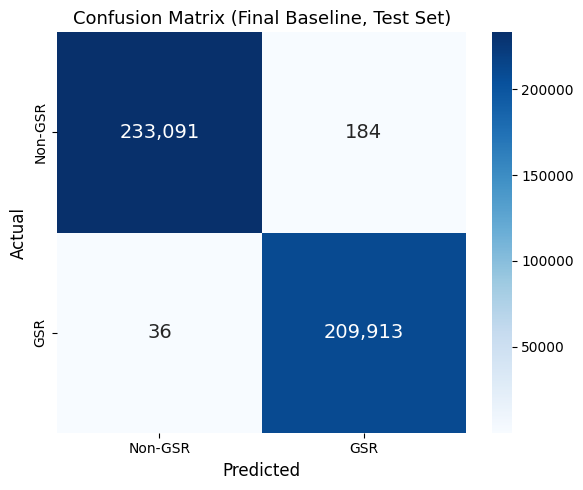

In [91]:
# === CONFUSION MATRIX HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm.reshape(2, 2), annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-GSR', 'GSR'],
            yticklabels=['Non-GSR', 'GSR'], ax=ax,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Final Baseline, Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

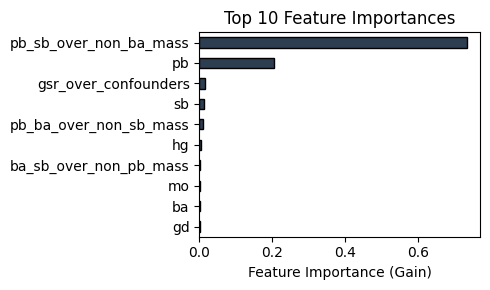

In [92]:
importances = baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

# Show top 10
top_n = feat_imp.tail(10)

fig, ax = plt.subplots(figsize=(5, 3))
top_n.plot(kind='barh', ax=ax, color='#2c3e50', edgecolor='black')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

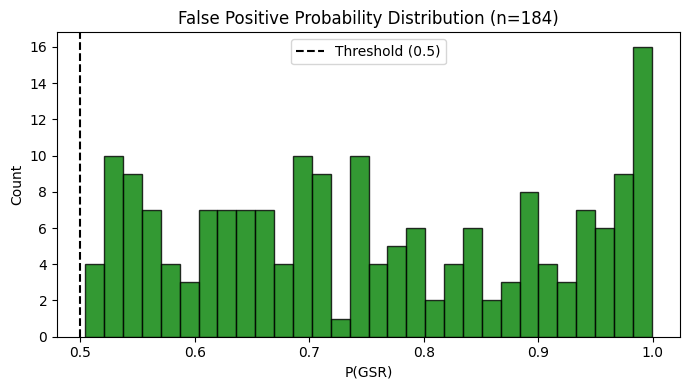

In [93]:
# === FP PROBABILITY DISTRIBUTION HISTOGRAM ===
fp_probs = y_prob_test[fp_mask]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fp_probs, bins=30, color='green', edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
ax.set_xlabel('P(GSR)')
ax.set_ylabel('Count')
ax.set_title(f'False Positive Probability Distribution (n={len(fp_probs)})')
ax.legend()
plt.tight_layout()
plt.savefig('fp_prob_dist.png', dpi=150)
plt.show()

### Recall on GSR subclasses / Specificity on Non-GSR subclasses

In [94]:
test_classes = eng_df['class'].values[test_idx]
test_labels = eng_df['label'].values[test_idx]
 
# Default-threshold predictions (already computed above as y_pred_test).
subclass_results = []
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_preds = y_pred_test[mask]
    cls_true  = y_test[mask]
    acc = (cls_preds == cls_true).mean()
    if label == 'GSR':
        rate = cls_preds.mean()              # recall = P(predicted=1 | actual=1)
        metric_name = 'Recall'
    else:
        rate = 1 - cls_preds.mean()           # specificity = P(predicted=0 | actual=0)
        metric_name = 'Specificity'
    subclass_results.append({
        'Class': cls, 'Label': label, 'N': int(n),
        'Accuracy': f'{acc:.4f}', metric_name: f'{rate:.4f}',
    })
 
subclass_df = pd.DataFrame(subclass_results)
print("Per-subclass performance (XGBoost, threshold=0.5):")
print(subclass_df.to_string(index=False))

Per-subclass performance (XGBoost, threshold=0.5):
 Class   Label      N Accuracy Specificity Recall
  BaAl Non_GSR  65221   0.9979      0.9979    NaN
BaCaSi Non_GSR  81503   0.9995      0.9995    NaN
  BaSb     GSR  20708   0.9993         NaN 0.9993
  CuZn Non_GSR  75472   1.0000      1.0000    NaN
GaCuSn Non_GSR    426   1.0000      1.0000    NaN
    Hg Non_GSR    678   1.0000      1.0000    NaN
  PbBa     GSR  48129   0.9997         NaN 0.9997
PbBaSb     GSR 108047   1.0000         NaN 1.0000
  PbSb     GSR  33065   0.9998         NaN 0.9998
TiZnGd Non_GSR   3434   0.9991      0.9991    NaN
  ZnTi Non_GSR   6541   1.0000      1.0000    NaN


### Threshold Optimization

In [95]:
val_prob = baseline.predict_proba(X_val)[:, 1]
test_prob = y_prob_test  # already computed above
 
def pick_thresholds(y_true, probs):
    """Returns (high_spec, balanced, high_sens) thresholds."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    balanced_thr = thresholds[np.argmax(f1s)]
 
    high_spec_mask = precisions[:-1] >= 0.9999
    if high_spec_mask.any():
        idx = np.where(high_spec_mask)[0][np.argmax(recalls[:-1][high_spec_mask])]
        high_spec_thr = thresholds[idx]
    else:
        high_spec_thr = 0.99
 
    high_sens_mask = recalls[:-1] >= 0.999
    if high_sens_mask.any():
        idx = np.where(high_sens_mask)[0][np.argmax(precisions[:-1][high_sens_mask])]
        high_sens_thr = thresholds[idx]
    else:
        high_sens_thr = 0.01
    return high_spec_thr, balanced_thr, high_sens_thr
 
# Pick on val (forensically correct).
high_spec_val, balanced_val, high_sens_val = pick_thresholds(y_val, val_prob)
 
print("Thresholds picked on VAL (forensically honest):")
print(f"  High-specificity : {high_spec_val:.4f}")
print(f"  Balanced (F1)    : {balanced_val:.4f}")
print(f"  High-sensitivity : {high_sens_val:.4f}")

Thresholds picked on VAL (forensically honest):
  High-specificity : 0.9759
  Balanced (F1)    : 0.5266
  High-sensitivity : 0.7506


In [96]:
def eval_at(thr, label):
    pred = (test_prob >= thr).astype(int)
    cm_t = confusion_matrix(y_test, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm_t.ravel()
    return {
        'Operating point': label,
        'Threshold': f'{thr:.4f}',
        'TN': int(tn_), 'FP': int(fp_), 'FN': int(fn_), 'TP': int(tp_),
        'FPR': f'{fp_/(fp_+tn_):.6f}',
        'FNR': f'{fn_/(fn_+tp_):.6f}',
        'F1':  f'{f1_score(y_test, pred):.6f}',
    }
 
rows = [
    eval_at(0.5,            'Default (0.5)'),
    eval_at(high_spec_val,  'High-specificity (val-picked)'),
    eval_at(balanced_val,   'Balanced F1 (val-picked)'),
    eval_at(high_sens_val,  'High-sensitivity (val-picked)'),
]
threshold_df = pd.DataFrame(rows)
print("Test-set metrics at each operating point (thresholds picked on val):")
print(threshold_df.to_string(index=False))

Test-set metrics at each operating point (thresholds picked on val):
              Operating point Threshold     TN  FP   FN     TP      FPR      FNR       F1
                Default (0.5)    0.5000 233091 184   36 209913 0.000789 0.000171 0.999476
High-specificity (val-picked)    0.9759 233255  20 1032 208917 0.000086 0.004915 0.997489
     Balanced F1 (val-picked)    0.5266 233100 175   45 209904 0.000750 0.000214 0.999476
High-sensitivity (val-picked)    0.7506 233189  86  202 209747 0.000369 0.000962 0.999314


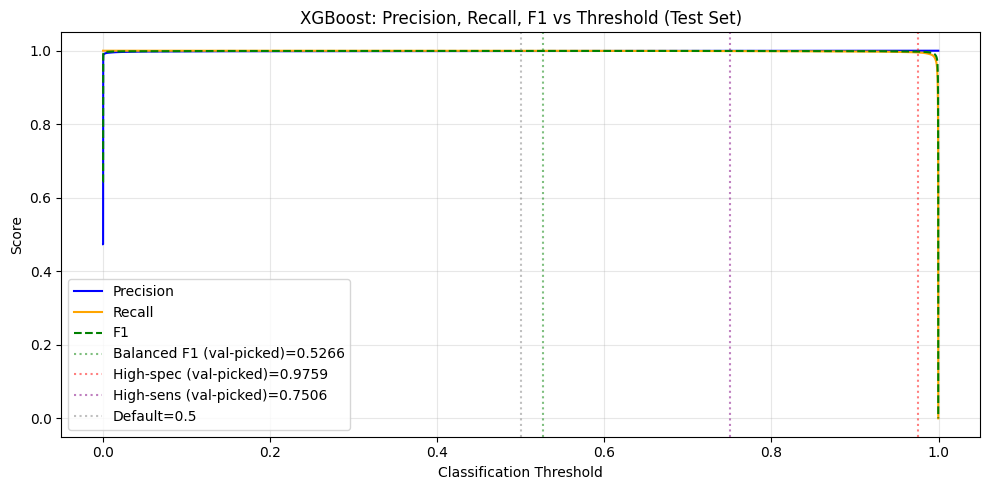

In [97]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='blue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
ax.plot(thresholds, f1_scores,       label='F1', color='green', linestyle='--')
ax.axvline(balanced_val,  color='green', alpha=0.5, linestyle=':',
           label=f'Balanced F1 (val-picked)={balanced_val:.4f}')
ax.axvline(high_spec_val, color='red',   alpha=0.5, linestyle=':',
           label=f'High-spec (val-picked)={high_spec_val:.4f}')
ax.axvline(high_sens_val, color='purple', alpha=0.5, linestyle=':',
           label=f'High-sens (val-picked)={high_sens_val:.4f}')
ax.axvline(0.5, color='gray', alpha=0.5, linestyle=':', label='Default=0.5')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost: Precision, Recall, F1 vs Threshold (Test Set)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_threshold_sweep.png', dpi=150)
plt.show()

### SHAP analysis

In [98]:
import shap

explainer = shap.TreeExplainer(baseline)
 
rng = np.random.RandomState(42)
shap_sample_size = min(5000, len(X_test))
shap_idx = rng.choice(len(X_test), size=shap_sample_size, replace=False)
X_shap = X_test[shap_idx]
 
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values computed: {shap_values.shape}")

SHAP values computed: (5000, 96)


In [99]:
# Global Feature Importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = (
    pd.Series(mean_abs_shap, index=feature_cols)
    .sort_values(ascending=False)
)
print("Top 20 features by mean |SHAP|:")
print(shap_imp.head(20))
 
# Compare to gain-based ranking.
gain_imp = pd.Series(baseline.feature_importances_, index=feature_cols)
comparison = pd.DataFrame({
    'shap_rank': shap_imp.rank(ascending=False).astype(int),
    'gain_rank': gain_imp.rank(ascending=False).astype(int),
    'mean_abs_shap': shap_imp,
    'gain': gain_imp,
}).sort_values('shap_rank').head(15)
print("\nSHAP vs gain ranking (top 15 by SHAP):")
print(comparison.to_string())

Top 20 features by mean |SHAP|:
pb_sb_over_non_ba_mass    4.720325
sb                        0.938597
pb                        0.879325
ba_sb_over_non_pb_mass    0.443818
pb_ba_over_non_sb_mass    0.338286
gsr_over_confounders      0.295690
al                        0.089681
ba                        0.082189
cu_zn_over_mass           0.049467
hg                        0.033722
s                         0.027785
as                        0.024547
cu                        0.018505
fe                        0.018071
ti_zn_over_mass           0.016010
si                        0.014957
k                         0.014434
o                         0.013370
ca                        0.011490
ti                        0.009670
dtype: float32

SHAP vs gain ranking (top 15 by SHAP):
                        shap_rank  gain_rank  mean_abs_shap      gain
pb_sb_over_non_ba_mass          1          1       4.720325  0.733378
sb                              2          4       0.938597  0.013364
pb 

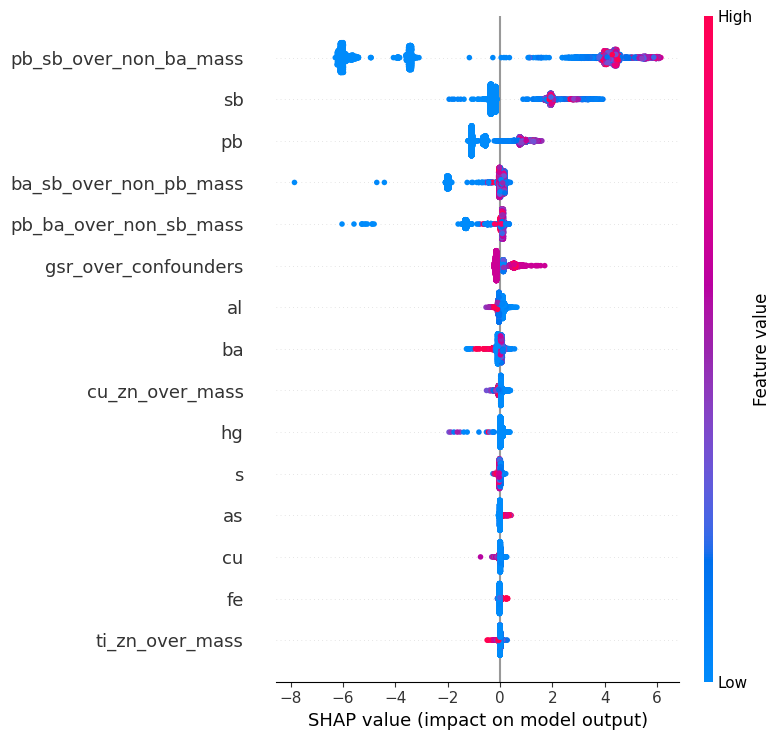

In [100]:
# SHAP summary plot
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

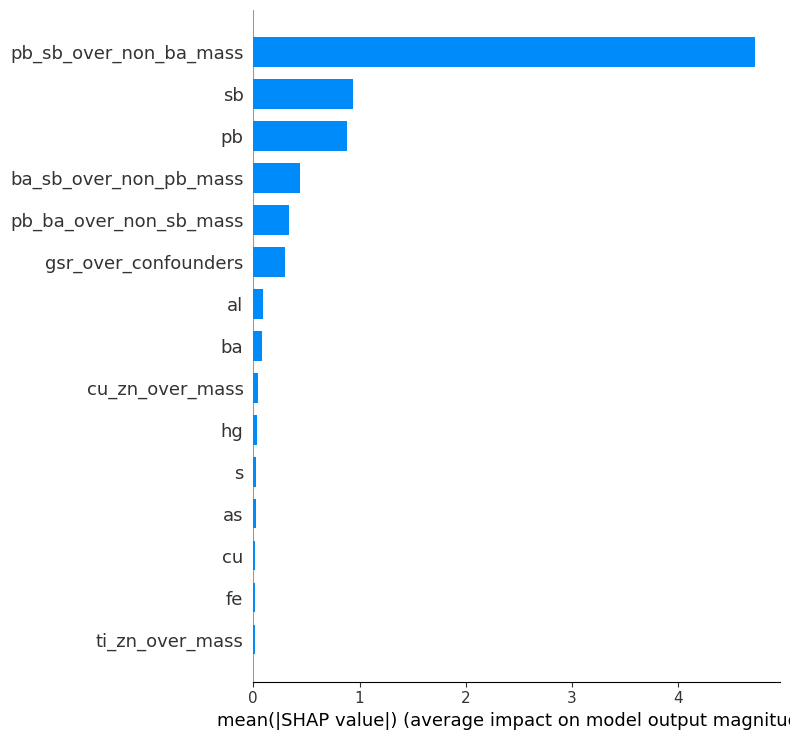

In [101]:
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# Per-particle SHAP attribution for the false positives.
# For each FP, the top 3 features pushing toward GSR are listed
fp_indices_full = np.where(fp_mask)[0]
print(f"Computing SHAP for {len(fp_indices_full)} false positives...")
 
shap_fp = explainer.shap_values(X_test[fp_indices_full])
 
df_test_full = eng_df.iloc[test_idx].reset_index(drop=True)
fp_records = []
for i, idx in enumerate(fp_indices_full):
    row = df_test_full.iloc[idx]
    contributions = pd.Series(shap_fp[i], index=feature_cols)
    # Top 3 features pushing prediction toward GSR (positive SHAP).
    top_pos = contributions.nlargest(3)
    fp_records.append({
        'stub_id': row['stub_id'],
        'particle_id': row['particle_id'],
        'class': row['class'],
        'prob': test_prob[idx],
        'top_feature_1': top_pos.index[0],
        'shap_1': top_pos.iloc[0],
        'top_feature_2': top_pos.index[1],
        'shap_2': top_pos.iloc[1],
        'top_feature_3': top_pos.index[2],
        'shap_3': top_pos.iloc[2],
    })
fp_shap_df = pd.DataFrame(fp_records).sort_values('prob', ascending=False)
print("\nTop-15 highest-confidence FPs with SHAP attribution:")
print(fp_shap_df.head(15).to_string(index=False))
fp_shap_df.to_csv('xgb_fp_shap_attribution.csv', index=False)
 
# Aggregate: which features most often drive FPs?
fp_top_feature_counts = fp_shap_df['top_feature_1'].value_counts()
print(f"\nWhich features most often drive FPs (top-1 SHAP):")
print(fp_top_feature_counts.head(10))

Computing SHAP for 184 false positives...

Top-15 highest-confidence FPs with SHAP attribution:
 stub_id  particle_id  class     prob          top_feature_1   shap_1          top_feature_2   shap_2        top_feature_3   shap_3
     375         6058 BaCaSi 0.999264 pb_sb_over_non_ba_mass 5.822916                     pb 1.418507 gsr_over_confounders 0.518028
     803         4703   BaAl 0.998656                     sb 3.611531 pb_sb_over_non_ba_mass 2.569614 gsr_over_confounders 0.749657
     911         2455 BaCaSi 0.997607 pb_sb_over_non_ba_mass 4.124770   gsr_over_confounders 0.749434                   pb 0.736942
    1219         3063 TiZnGd 0.997397 pb_sb_over_non_ba_mass 4.165396                     sb 1.755699                   pb 0.880425
    1219         9806 TiZnGd 0.997186 pb_sb_over_non_ba_mass 3.322446                     sb 2.952386 gsr_over_confounders 0.652734
    3011         2047   BaAl 0.995987 pb_sb_over_non_ba_mass 5.817140                     pb 1.161064 gsr_over_c

### Per-Tree Variance (XGB Uncertainty)

In [103]:
best_iter = baseline.best_iteration
# Sample prediction trajectories at evenly-spaced rounds late in training.
# Using late rounds (after the model has stabilized) avoids picking up
# early-training noise.
sample_rounds = np.linspace(
    max(1, best_iter // 2), best_iter, num=20, dtype=int
)
sample_rounds = np.unique(sample_rounds)
print(f"Sampling predictions at rounds: {sample_rounds.tolist()}")
 
prob_trajectories = np.zeros((len(sample_rounds), len(X_test)))
for i, k in enumerate(sample_rounds):
    prob_trajectories[i] = baseline.predict_proba(
        X_test, iteration_range=(0, int(k))
    )[:, 1]
 
mean_pred = prob_trajectories.mean(axis=0)
std_pred  = prob_trajectories.std(axis=0)
 
print(f"\nPrediction stability across late boosting rounds:")
print(f"  Mean std : {std_pred.mean():.6f}")
print(f"  Max std  : {std_pred.max():.6f}")
print(f"  Particles with std > 0.05 : {(std_pred > 0.05).sum():,} "
      f"({(std_pred > 0.05).mean():.2%})")
print(f"  Particles with std > 0.10 : {(std_pred > 0.10).sum():,} "
      f"({(std_pred > 0.10).mean():.2%})")

Sampling predictions at rounds: [34, 35, 37, 39, 41, 43, 45, 46, 48, 50, 52, 54, 56, 57, 59, 61, 63, 65, 67, 69]

Prediction stability across late boosting rounds:
  Mean std : 0.004845
  Max std  : 0.261227
  Particles with std > 0.05 : 165 (0.04%)
  Particles with std > 0.10 : 60 (0.01%)


In [104]:
print(f"{'Class':>10} {'Label':>8} {'N':>8} {'Mean Std':>10} "
      f"{'Max Std':>10} {'Std>0.05':>10}")
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_std = std_pred[mask]
    print(f"{cls:>10} {label:>8} {n:>8} {cls_std.mean():>10.6f} "
          f"{cls_std.max():>10.6f} {(cls_std > 0.05).sum():>10,}")

     Class    Label        N   Mean Std    Max Std   Std>0.05
      BaAl  Non_GSR    65221   0.004988   0.261227         95
    BaCaSi  Non_GSR    81503   0.004733   0.211498         27
      BaSb      GSR    20708   0.005422   0.071422          5
      CuZn  Non_GSR    75472   0.004680   0.069560          3
    GaCuSn  Non_GSR      426   0.004665   0.004680          0
        Hg  Non_GSR      678   0.005166   0.009867          0
      PbBa      GSR    48129   0.005084   0.144810         34
    PbBaSb      GSR   108047   0.004775   0.017576          0
      PbSb      GSR    33065   0.004763   0.078841          1
    TiZnGd  Non_GSR     3434   0.004694   0.028801          0
      ZnTi  Non_GSR     6541   0.004755   0.020332          0


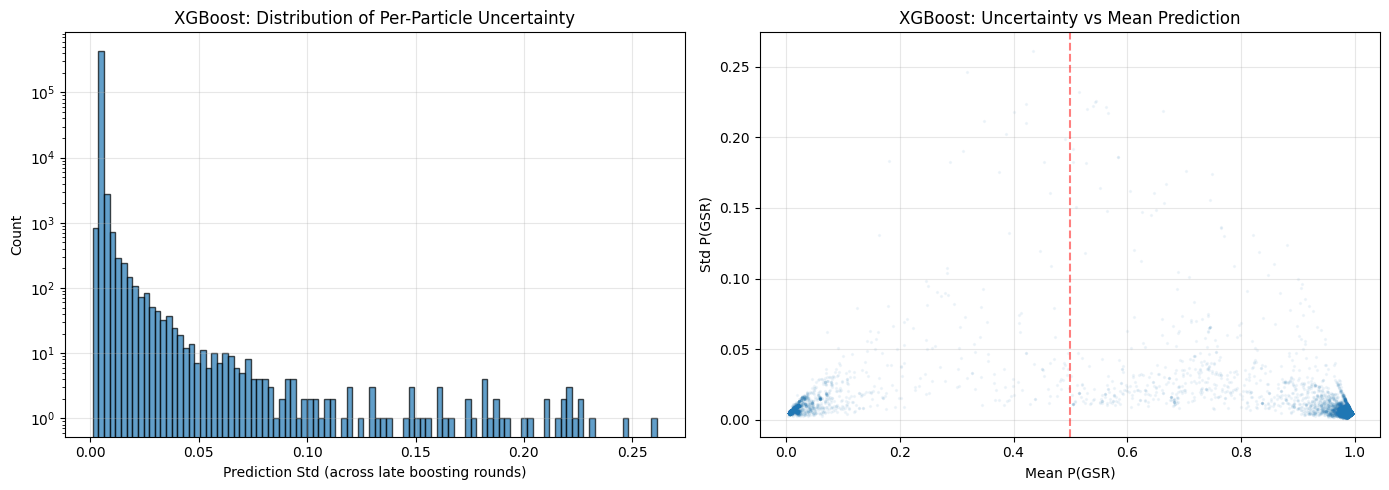

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(std_pred, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Std (across late boosting rounds)')
axes[0].set_ylabel('Count')
axes[0].set_title('XGBoost: Distribution of Per-Particle Uncertainty')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
 
axes[1].scatter(mean_pred, std_pred, alpha=0.05, s=2)
axes[1].set_xlabel('Mean P(GSR)')
axes[1].set_ylabel('Std P(GSR)')
axes[1].set_title('XGBoost: Uncertainty vs Mean Prediction')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_uncertainty.png', dpi=150)
plt.show()

In [106]:
fp_std = std_pred[fp_mask]
tn_std = std_pred[(y_pred_test == 0) & (y_test == 0)]
print(f"FP particles : mean std = {fp_std.mean():.6f}, "
      f"median = {np.median(fp_std):.6f}")
print(f"TN particles : mean std = {tn_std.mean():.6f}, "
      f"median = {np.median(tn_std):.6f}")
print(f"Ratio        : {fp_std.mean() / max(tn_std.mean(), 1e-12):.1f}x")

FP particles : mean std = 0.032844, median = 0.020129
TN particles : mean std = 0.004766, median = 0.004676
Ratio        : 6.9x


# Ambiguous Particles

In [107]:
nfi_df = pd.read_parquet("../../../data/raw/NFI/nfi_particle_data_full.parquet")
nfi_df.shape

(2801667, 106)

In [108]:
nfi_df['merged_relevance_class'].unique()

<ArrowStringArray>
[    'PbSb',   'PbSbBa',       'Sb',       'Pb',     'PbBa',     'BaSb',
       'Ba',     'CuZn',   'BaCaSi',     'BaAl',       'Sr',     'ZnTi',
   'TiZnGd',       'Hg',     'BaSn',     'SbHg', 'PbSbBaSn',   'GaCuSn',
 'PbSbBaSr']
Length: 19, dtype: str

In [109]:
element_cols = [c for c in nfi_df.columns if 1 <= len(c) <= 2]
filtered = nfi_df[['stub_id', 'particle_id', 'merged_relevance_class'] + element_cols]
filtered = filtered.drop(columns='id')  # remove 'id' if it was included
element_cols = [c for c in filtered.columns if 1 <= len(c) <= 2]
len(element_cols)

89

In [110]:
amb_89 = filtered[filtered['merged_relevance_class'].isin(['Sb', 'Pb', 'Ba', 'Sr', 'BaSi', 'BaSn', 'BaSr'])]
amb_89.shape

(506682, 92)

In [111]:
amb_89 = (
    amb_89
    .rename(columns={'merged_relevance_class': 'final_class'})
    .assign(final_class=lambda d: d['final_class'].replace({'BaSn': 'Ba'}))
)

print(amb_89["final_class"].value_counts())

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [112]:
amb_89['label'] = 'Ambiguous'

In [113]:
df_amb = pd.read_parquet("../../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


__Rejoin original ambiguous dataset w/ preprocessed ambiguous dataset (all 89 elements)__

In [114]:
keys = ['stub_id', 'particle_id']
drop_extra = ['relevance_class', 'merged_relevance_class']

# columns in df_amb that overlap with amb_89 (other than the keys) -> drop from df_amb to avoid dupes
overlap = [c for c in df_amb.columns if c in amb_89.columns and c not in keys]
df_amb_trim = df_amb.drop(columns=overlap)

merged = amb_89.merge(df_amb_trim, on=keys, how='inner')
merged = merged.drop(columns=[c for c in drop_extra if c in merged.columns])
print(f"Merged dataset shape: {merged.shape}")

Merged dataset shape: (506682, 93)


In [115]:
amb_meta_cols = ['stub_id', 'particle_id', 'final_class', 'label']
amb_element_cols = [c for c in merged.columns if c not in amb_meta_cols]
len(amb_element_cols)

89

In [116]:
eng_amb = merged.copy()

In [117]:
# Pb * Sb
eng_amb['pb_times_sb'] = eng_amb['pb'] * (eng_amb['sb'])

In [118]:
# Log (Pb + Sb)
# eng_amb['log_pb_plus_sb'] = np.log1p(eng_amb['pb'] + eng_amb['sb'])

In [119]:
# GSR ratios over total mass
total_mass = eng_amb[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_amb['sb']
total_mass_no_ba = total_mass - eng_amb['ba']
total_mass_no_pb = total_mass - eng_amb['pb']

eng_amb['pb_ba_over_non_sb_mass'] = (eng_amb['pb'] + eng_amb['ba']) / total_mass_no_sb
eng_amb['pb_sb_over_non_ba_mass'] =  (eng_amb['pb'] + eng_amb['sb']) / total_mass_no_ba
eng_amb['ba_sb_over_non_pb_mass'] =  (eng_amb['ba'] + eng_amb['sb']) / total_mass_no_pb

In [120]:
# Brass particles
eng_amb['cu_zn_over_mass'] =  (eng_amb['cu'] + eng_amb['zn']) / total_mass

# Titanium Zinc
eng_amb['ti_zn_over_mass'] = (eng_amb['ti'] + eng_amb['zn']) / total_mass

In [121]:
# Non-Barium GSR over Non-Barium Confounders
gsr = eng_amb['pb'] + eng_amb['sb']
confounders = eng_amb['ca'] + eng_amb['si'] + eng_amb['al'] + eng_amb['fe'] #+ eng_amb['ti'] + eng_amb['zn'] + eng_amb['cu']
eng_amb['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_amb['gsr_over_confounders']) | eng_amb['gsr_over_confounders'].isna())

False

In [122]:
eng_amb.columns

Index(['stub_id', 'particle_id', 'final_class', 'ac', 'ag', 'al', 'ar', 'as',
       'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr',
       'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf',
       'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo',
       'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb',
       'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru',
       's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te',
       'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr',
       'label', 'pb_times_sb', 'pb_ba_over_non_sb_mass',
       'pb_sb_over_non_ba_mass', 'ba_sb_over_non_pb_mass', 'cu_zn_over_mass',
       'ti_zn_over_mass', 'gsr_over_confounders'],
      dtype='str')

In [123]:
eng_amb_cols = [c for c in eng_amb.columns if c not in amb_meta_cols + amb_element_cols]
print(f"# of engineered features: {len(eng_amb_cols)}")
print(f"\nEngineered features:")
for feat in eng_amb_cols:
    print(f"\t{feat}")

# of engineered features: 7

Engineered features:
	pb_times_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


__7 engineered features + 89 raw element features__

In [124]:
feature_amb_cols = amb_element_cols + eng_amb_cols
print(f"# of feature columns: {len(feature_amb_cols)}")

# of feature columns: 96


### Run Model against Ambiguous Particles

In [125]:
model = baseline

In [126]:
X_amb = eng_amb[feature_amb_cols].values.astype(np.float32)

probs_amb = model.predict_proba(X_amb)[:, 1]
preds_amb = (probs_amb >= 0.97).astype(int)

eng_amb = eng_amb.assign(prob_gsr=probs_amb, pred_gsr=preds_amb)

n = len(eng_amb)
n_gsr = int(preds_amb.sum())
print(f'Particles scored : {n:,}')
print(f'Predicted GSR    : {n_gsr:,}  ({n_gsr / n:.1%})')
print(f'Predicted Non-GSR: {n - n_gsr:,}  ({1 - n_gsr / n:.1%})')
print(f'\nProbability distribution:')
print(pd.Series(probs_amb).describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(4))
print(f'\nPredicted GSR by final_class:')
agg = (
    eng_amb.groupby('final_class')
           .agg(n=('pred_gsr', 'size'),
                pred_gsr=('pred_gsr', 'sum'),
                mean_prob=('prob_gsr', 'mean'))
)
agg['pct_gsr'] = agg['pred_gsr'] / agg['n'] * 100
agg = agg.sort_values('pct_gsr', ascending=False)
print(agg.round(2))

Particles scored : 506,682
Predicted GSR    : 1,414  (0.3%)
Predicted Non-GSR: 505,268  (99.7%)

Probability distribution:
count    506682.0000
mean          0.2718
std           0.3600
min           0.0004
10%           0.0005
25%           0.0024
50%           0.0157
75%           0.7050
90%           0.8531
95%           0.8796
max           0.9995
dtype: float64

Predicted GSR by final_class:
                  n  pred_gsr  mean_prob  pct_gsr
final_class                                      
Pb           168334       794       0.05     0.47
Ba            89277       177       0.01     0.20
Sb           225676       443       0.57     0.20
Sr            23395         0       0.00     0.00


In [127]:
print(f'Overall pct_gsr (manual): {eng_amb["pred_gsr"].mean() * 100:.2f}%')
print(f'Weighted from agg:        {(agg["pred_gsr"].sum() / agg["n"].sum()) * 100:.2f}%')
print(agg[["n", "pred_gsr", "pct_gsr"]])

Overall pct_gsr (manual): 0.28%
Weighted from agg:        0.28%
                  n  pred_gsr   pct_gsr
final_class                            
Pb           168334       794  0.471681
Ba            89277       177  0.198259
Sb           225676       443  0.196299
Sr            23395         0  0.000000


__9% of Sb particles predicted as GSR ... Wow ...__

In [128]:
sb_mask = (eng_amb['final_class'] == 'Sb')
sb_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 1)]
sb_not_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 0)]

# Compare elemental compositions
print(sb_flagged[element_cols].describe())
print(sb_not_flagged[element_cols].describe())

# Are these "purely Sb" or do they have trace other elements?
sb_flagged['n_elements'] = (sb_flagged[element_cols] > 0).sum(axis=1)
print(sb_flagged['n_elements'].value_counts())

          ac     ag          al     ar          as     at     au      b  \
count  443.0  443.0  443.000000  443.0  443.000000  443.0  443.0  443.0   
mean     0.0    0.0    1.875519    0.0    0.000543    0.0    0.0    0.0   
std      0.0    0.0    2.891139    0.0    0.011428    0.0    0.0    0.0   
min      0.0    0.0    0.000000    0.0    0.000000    0.0    0.0    0.0   
25%      0.0    0.0    0.000000    0.0    0.000000    0.0    0.0    0.0   
50%      0.0    0.0    0.938869    0.0    0.000000    0.0    0.0    0.0   
75%      0.0    0.0    1.978244    0.0    0.000000    0.0    0.0    0.0   
max      0.0    0.0   17.379601    0.0    0.240525    0.0    0.0    0.0   

               ba          bi  ...     tl     tm      u      v      w     xe  \
count  443.000000  443.000000  ...  443.0  443.0  443.0  443.0  443.0  443.0   
mean     0.401560    0.040478  ...    0.0    0.0    0.0    0.0    0.0    0.0   
std      0.453219    0.657462  ...    0.0    0.0    0.0    0.0    0.0    0.0   
min 

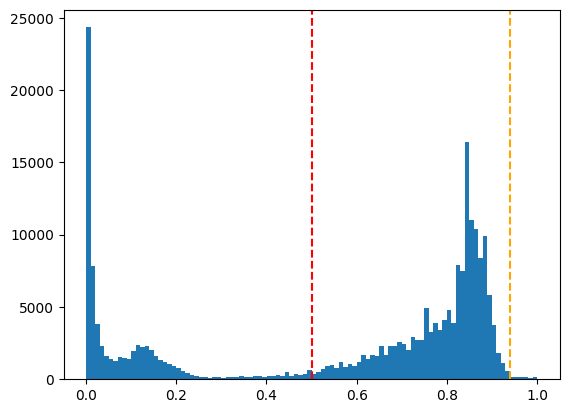

In [129]:
sb_probs = probs_amb[sb_mask]
plt.hist(sb_probs, bins=100)
plt.axvline(0.5, color='red', linestyle='--')
plt.axvline(0.94, color='orange', linestyle='--', label='your threshold')

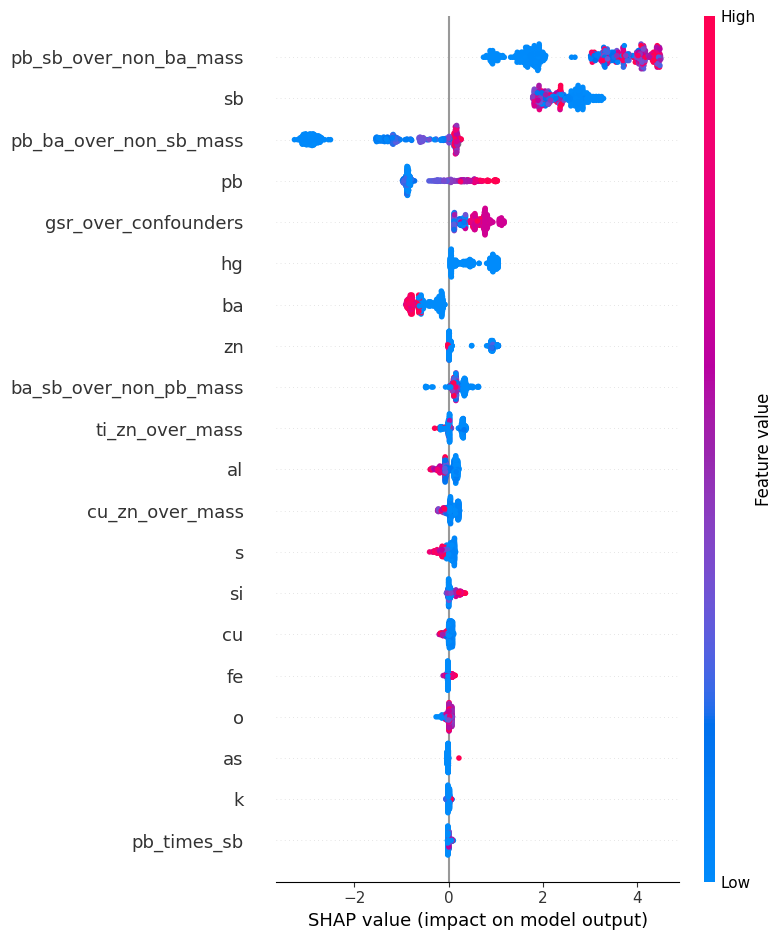

In [130]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]

amb_explainer = shap.TreeExplainer(model)

shap_values_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])
shap.summary_plot(shap_values_sb, X_amb[sb_flagged_idx], feature_names=feature_amb_cols)

In [131]:
# Antimony SHAP attribution for the ambiguous GSR predictions.
# For every Sb-class particle that the model flagged as GSR, list the top 3
# features pushing the prediction toward GSR (largest positive SHAP).
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]
print(f"Computing SHAP for {len(sb_flagged_idx)} Sb particles flagged as GSR...")

shap_sb = explainer.shap_values(X_amb[sb_flagged_idx])

eng_amb_reset = eng_amb.reset_index(drop=True)
sb_records = []
for i, idx in enumerate(sb_flagged_idx):
    row = eng_amb_reset.iloc[idx]
    contributions = pd.Series(shap_sb[i], index=feature_amb_cols)
    top_pos = contributions.nlargest(3)
    sb_records.append({
        'stub_id': row['stub_id'],
        'particle_id': row['particle_id'],
        'final_class': row['final_class'],
        'prob': probs_amb[idx],
        'top_feature_1': top_pos.index[0],
        'shap_1': top_pos.iloc[0],
        'top_feature_2': top_pos.index[1],
        'shap_2': top_pos.iloc[1],
        'top_feature_3': top_pos.index[2],
        'shap_3': top_pos.iloc[2],
    })
sb_shap_df = pd.DataFrame(sb_records).sort_values('prob', ascending=False)
print("Top-15 highest-confidence Sb-flagged particles with SHAP attribution:")
print(sb_shap_df.head(15).to_string(index=False))
sb_shap_df.to_csv('xgb_sb_amb_shap_attribution.csv', index=False)

# Aggregate: which features most often drive these Sb-class flags?
sb_top_feature_counts = sb_shap_df['top_feature_1'].value_counts()
print(f"Which features most often drive Sb-class GSR flags (top-1 SHAP):")
print(sb_top_feature_counts.head(10))


Computing SHAP for 443 Sb particles flagged as GSR...
Top-15 highest-confidence Sb-flagged particles with SHAP attribution:
 stub_id  particle_id final_class     prob          top_feature_1   shap_1 top_feature_2   shap_2 top_feature_3   shap_3
     180         6463          Sb 0.999532 pb_sb_over_non_ba_mass 4.475419            sb 1.814180            pb 0.989216
     773         3320          Sb 0.999532 pb_sb_over_non_ba_mass 4.473716            sb 1.816049            pb 0.989814
     180         5853          Sb 0.999532 pb_sb_over_non_ba_mass 4.476532            sb 1.816238            pb 0.989851
    2795         1349          Sb 0.999532 pb_sb_over_non_ba_mass 4.468784            sb 1.816631            pb 0.989814
    1521         3586          Sb 0.999532 pb_sb_over_non_ba_mass 4.477815            sb 1.799058            pb 0.997600
     773         3314          Sb 0.999526 pb_sb_over_non_ba_mass 4.153365            sb 1.790208            pb 1.016075
     773         3498        